# Zershot Finnish 3 models


In [32]:
!pip install datasets transformers pandas scikit-learn tqdm --quiet

import pandas as pd
import os
from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [31]:
def load_goemotions():
    dataset = load_dataset("go_emotions", "simplified", split="train")
    df = pd.DataFrame(dataset)
    df['label'] = df['labels'].apply(lambda x: x[0] if x else -1)
    df = df[df['label'] != -1]
    return df[['text', 'label']]

go_df = load_goemotions()
go_df.head()


,text,label
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


In [33]:

!pip install transformers datasets scikit-learn pandas tqdm seaborn --quiet

In [34]:

from datasets import load_dataset
from transformers import pipeline
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()

In [35]:

dataset = load_dataset("Helsinki-NLP/xed_en_fi", "fi_annotated", split="train")
df = pd.DataFrame(dataset)
print(df.head())

                                            sentence     labels
0  Kuinka se vapautui niin nopeasti, mutta sinä e...  [1, 3, 7]
1  Ruumiita ripustettuina - ruumiita, joiden nahk...  [1, 3, 4]
2                                  Ei mitään muttia.        [1]
3                    Älä anna hänen määräillä sinua!        [1]
4                                Laske aseet maahan.     [1, 4]


In [36]:
# Emotion ID mapping (as per documentation)
emotion_map = {
    0: "neutral",
    1: "anger",
    2: "anticipation",
    3: "disgust",
    4: "fear",
    5: "joy",
    6: "sadness",
    7: "surprise",
    8: "trust"
}

# Remove rows with empty or null labels
df = df[df['labels'].notnull() & df['sentence'].notnull()]

# Convert first label only (for zero-shot classification)
import random
df['labels'] = df['labels'].apply(lambda x: emotion_map[random.choice(x)] if isinstance(x, list) else emotion_map[x])

# Final working DataFrame
df = df[['sentence', 'labels']].dropna().rename(columns={"sentence": "text"}).reset_index(drop=True)

# Show sample
df.head(20)

,text,labels
0,"Kuinka se vapautui niin nopeasti, mutta sinä e...",surprise
1,"Ruumiita ripustettuina - ruumiita, joiden nahk...",anger
2,Ei mitään muttia.,anger
3,Älä anna hänen määräillä sinua!,anger
4,Laske aseet maahan.,anger
5,Vittuun toimisto!,anger
6,Maksut pitää hoitaa ajallaan.,anger
7,Jollet halua viettää seuraavaa 20 vuotta vanki...,anger
8,"lntiaanirenki, juoppo pyssymies, seksihullu ja...",anger
9,Nyt virta katkesi jatkuvasti hänen omassa kodi...,anger


In [37]:
sample_df = df.sample(n=200, random_state=42).reset_index(drop=True)
candidate_labels = sorted(set(df["labels"]))
print("Emotions:", candidate_labels)

Emotions: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']


In [57]:
classifier = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [58]:
sample_df["predicted"] = sample_df["text"].progress_apply(
    lambda x: classifier(x, candidate_labels=candidate_labels, multi_label=False)["labels"][0]
)

100%|██████████| 200/200 [00:33<00:00,  5.92it/s]



📈 Classification Report:

              precision    recall  f1-score   support

       anger       0.50      0.07      0.12        44
anticipation       0.25      0.72      0.37        32
     disgust       0.50      0.17      0.26        23
        fear       0.50      0.09      0.15        22
         joy       0.85      0.35      0.50        31
     sadness       1.00      0.20      0.33        20
    surprise       0.14      0.69      0.23        13
       trust       0.12      0.07      0.09        15

    accuracy                           0.28       200
   macro avg       0.48      0.30      0.26       200
weighted avg       0.51      0.28      0.26       200



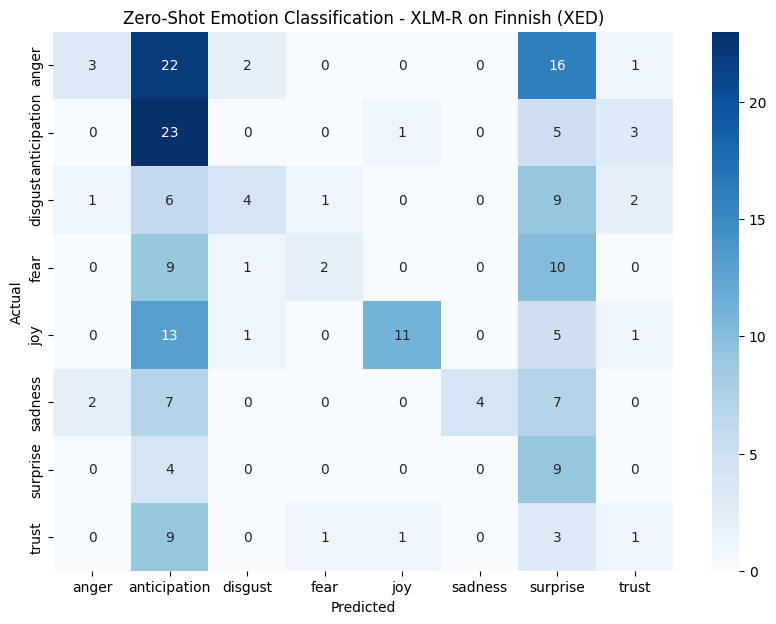

In [59]:
print("\n📈 Classification Report:\n")
print(classification_report(sample_df["labels"], sample_df["predicted"]))

# Confusion Matrix
sorted_labels = sorted(sample_df['labels'].unique())
cm = confusion_matrix(sample_df['labels'], sample_df['predicted'], labels=sorted_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=sorted_labels,
            yticklabels=sorted_labels,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot Emotion Classification - XLM-R on Finnish (XED)")
plt.show()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
100%|██████████| 200/200 [00:18<00:00, 10.91it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision 


📈 Classification Report (mBERT):

              precision    recall  f1-score   support

       anger       0.50      0.05      0.08        44
anticipation       0.00      0.00      0.00        32
     disgust       0.00      0.00      0.00        23
        fear       0.50      0.05      0.08        22
         joy       0.15      0.68      0.25        31
     sadness       0.00      0.00      0.00        20
    surprise       0.08      0.31      0.13        13
       trust       0.00      0.00      0.00        15

    accuracy                           0.14       200
   macro avg       0.15      0.13      0.07       200
weighted avg       0.19      0.14      0.07       200



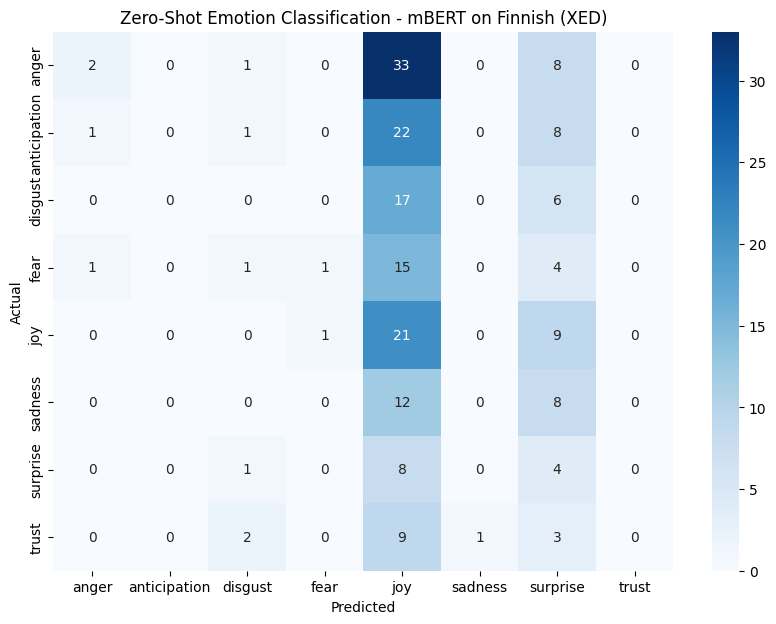

In [54]:
# prompt: for model mBERT do zero shot finnish using above preprocesing on fiinish

from transformers import pipeline

# Load the mBERT model for zero-shot classification
classifier = pipeline("zero-shot-classification", model="bert-base-multilingual-cased")

# Assuming 'df' is your DataFrame with 'text' and 'labels' columns (as in the previous code)
# ... (your existing code to load and preprocess the data) ...

sample_df["predicted_mbert"] = sample_df["text"].progress_apply(
    lambda x: classifier(x, candidate_labels=candidate_labels, multi_label=False)["labels"][0]
)

print("\n📈 Classification Report (mBERT):\n")
print(classification_report(sample_df["labels"], sample_df["predicted_mbert"]))

# Confusion Matrix for mBERT
cm_mbert = confusion_matrix(sample_df['labels'], sample_df['predicted_mbert'], labels=sorted_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_mbert, annot=True, fmt='d',
            xticklabels=sorted_labels,
            yticklabels=sorted_labels,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot Emotion Classification - mBERT on Finnish (XED)")
plt.show()


Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
100%|██████████| 200/200 [00:30<00:00,  6.63it/s]



📈 Classification Report (XLM-RoBERTa):

              precision    recall  f1-score   support

       anger       0.50      0.07      0.12        44
anticipation       0.25      0.72      0.37        32
     disgust       0.50      0.17      0.26        23
        fear       0.50      0.09      0.15        22
         joy       0.85      0.35      0.50        31
     sadness       1.00      0.20      0.33        20
    surprise       0.14      0.69      0.23        13
       trust       0.12      0.07      0.09        15

    accuracy                           0.28       200
   macro avg       0.48      0.30      0.26       200
weighted avg       0.51      0.28      0.26       200



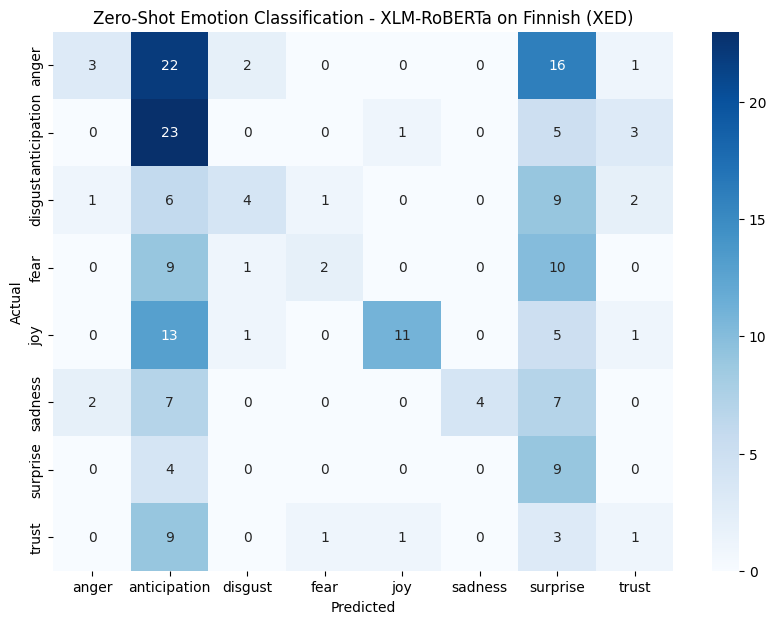

In [55]:
# prompt: xlm-r for finnish

# Assuming 'df' is your DataFrame with 'text' and 'labels' columns (as in the previous code)
# ... (your existing code to load and preprocess the data) ...

# Load the XLM-RoBERTa model for zero-shot classification
classifier = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")

# Assuming 'candidate_labels' is defined as before (sorted list of emotions)
# ... (your existing code to define candidate_labels) ...

sample_df["predicted_xlmr"] = sample_df["text"].progress_apply(
    lambda x: classifier(x, candidate_labels=candidate_labels, multi_label=False)["labels"][0]
)

print("\n📈 Classification Report (XLM-RoBERTa):\n")
print(classification_report(sample_df["labels"], sample_df["predicted_xlmr"]))

# Confusion Matrix for XLM-RoBERTa
cm_xlmr = confusion_matrix(sample_df['labels'], sample_df['predicted_xlmr'], labels=sorted_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_xlmr, annot=True, fmt='d',
            xticklabels=sorted_labels,
            yticklabels=sorted_labels,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot Emotion Classification - XLM-RoBERTa on Finnish (XED)")
plt.show()


In [62]:
# prompt: report_mbert = classification_report(sample_en["labels"], sample_en["predicted"], output_dict=True, zero_division=0)
# report_xlmr = classification_report(sample_en["labels"], sample_en["predicted"], output_dict=True, zero_division=0)
# same do for finnish on three models

report_mbert_fi = classification_report(sample_df["labels"], sample_df["predicted_mbert"], output_dict=True, zero_division=0)
report_xlmr_fi = classification_report(sample_df["labels"], sample_df["predicted_xlmr"], output_dict=True, zero_division=0)
report_xnli_fi= classification_report(sample_df["labels"], sample_df["predicted"], output_dict=True, zero_division=0)


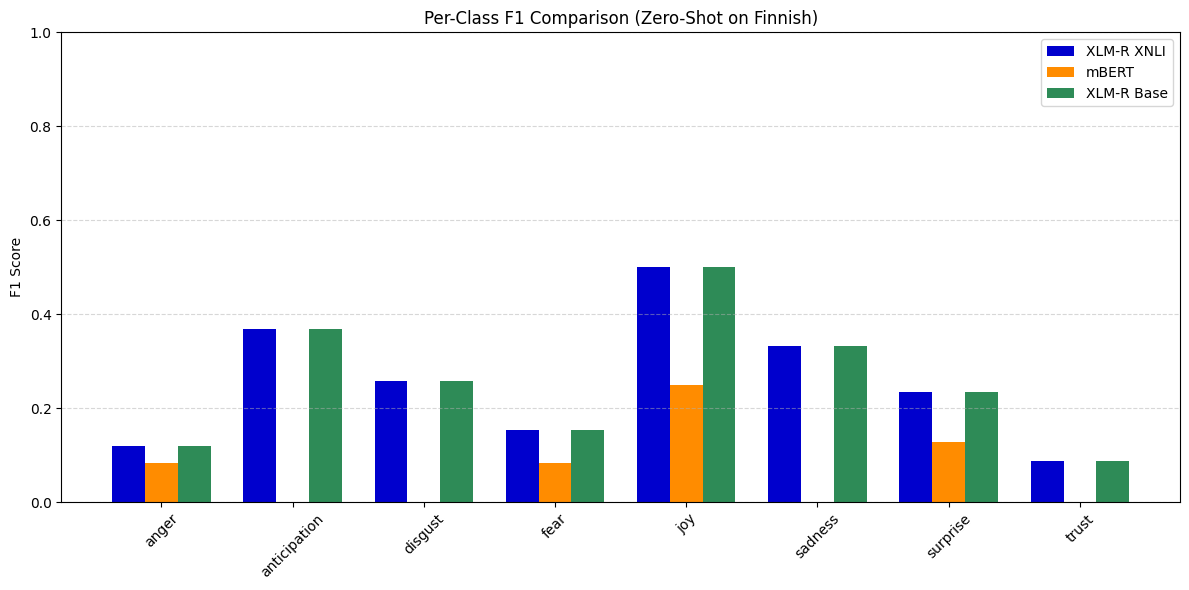

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Emotion labels in order
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# Extract F1 scores
f1_xnli_fi = [report_xnli_fi[label]['f1-score'] for label in emotion_labels]
f1_mbert_fi = [report_mbert_fi[label]['f1-score'] for label in emotion_labels]
f1_xlmr_fi = [report_xlmr_fi[label]['f1-score'] for label in emotion_labels]

# Plot setup
x = np.arange(len(emotion_labels))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, f1_xnli_fi, width=width, label="XLM-R XNLI", color='mediumblue')
plt.bar(x,         f1_mbert_fi, width=width, label="mBERT", color='darkorange')
plt.bar(x + width, f1_xlmr_fi, width=width, label="XLM-R Base", color='seagreen')

plt.xticks(x, emotion_labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison (Zero-Shot on Finnish)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Finetune phase 1  XLM-R



In [16]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 72.6 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.38.2
    Uninstalling transformers-4.38.2:
      Successfully uninstalled transformers-4.38.2


In [1]:
!pip install transformers datasets scikit-learn pandas tqdm --quiet


from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd
import random
from tqdm import tqdm


In [2]:
raw_dataset = load_dataset("go_emotions", "simplified")
train_df = pd.DataFrame(raw_dataset['train'])
test_df = pd.DataFrame(raw_dataset['test'])

train_df = train_df.sample(n=5000, random_state=42)
test_df = test_df.sample(n=1000, random_state=42)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
# ✅ 2. Keep only samples with at least one label, and randomly select one
train_df = train_df[train_df['labels'].map(len) > 0]
test_df = test_df[test_df['labels'].map(len) > 0]
train_df['label'] = train_df['labels'].apply(lambda x: int(random.choice(x)))
test_df['label'] = test_df['labels'].apply(lambda x: int(random.choice(x)))

# ✅ 3. Keep only necessary columns and convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

In [4]:
checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize(example):
    return tokenizer(example['text'], padding=True, truncation=True)

train_tokenized = train_dataset.map(tokenize, batched=True)
test_tokenized = test_dataset.map(tokenize, batched=True)


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
num_labels = len(set(train_df['label']))
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


<ipython-input-16-52bd86fbafb2>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [17]:
# ✅ 9. Train the model
trainer.train()

# 🔄 Save model for later use
trainer.save_model("./finetuned_xlmroberta_goemotions")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,2.674144,0.312000,0.148390
2,2.721800,2.150899,0.441000,0.302403
3,2.721800,1.923117,0.490000,0.395769
4,2.092600,1.862932,0.496000,0.422685
5,1.738600,1.871916,0.486000,0.427871


In [18]:
!pip install transformers datasets scikit-learn pandas tqdm seaborn --quiet


from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

In [19]:
xed_fi = load_dataset("Helsinki-NLP/xed_en_fi", "fi_annotated", split="train")

In [20]:
label_map = {
    0: "neutral", 1: "anger", 2: "anticipation", 3: "disgust", 4: "fear",
    5: "joy", 6: "sadness", 7: "surprise", 8: "trust"
}

In [21]:
xed_df = pd.DataFrame(xed_fi)
xed_df = xed_df[xed_df['labels'].map(lambda x: isinstance(x, list) and len(x) > 0)]
xed_df['labels'] = xed_df['labels'].apply(lambda x: x[0])
xed_df['label_name'] = xed_df['labels'].apply(lambda x: label_map[x])
xed_df = xed_df[['sentence', 'labels', 'label_name']].rename(columns={"sentence": "text"}).reset_index(drop=True)


In [22]:
model_path = "./finetuned_xlmroberta_goemotions"  # change this if using XLM-R
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [23]:
def tokenize_batch(batch_texts):
    return tokenizer(batch_texts, truncation=True, padding=True, return_tensors="pt")


In [24]:
predictions = []
batch_size = 16
for i in tqdm(range(0, len(xed_df), batch_size)):
    batch = xed_df.iloc[i:i+batch_size]
    inputs = tokenize_batch(batch['text'].tolist())
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, axis=1).cpu().numpy()
        predictions.extend(preds)

xed_df['predicted'] = predictions
xed_df['predicted_name'] = xed_df['predicted'].map(label_map)

100%|██████████| 904/904 [00:21<00:00, 42.16it/s]


In [25]:
# Drop rows with missing values in label or prediction
xed_clean = xed_df.dropna(subset=["label_name", "predicted_name"])

In [26]:
# Filter out rows where label or prediction is missing
xed_clean = xed_df.dropna(subset=["label_name", "predicted_name"])

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report (Finnish XED):\n")
print(classification_report(xed_clean['label_name'], xed_clean['predicted_name']))

cm = confusion_matrix(
    xed_clean['label_name'],
    xed_clean['predicted_name'],
    labels=list(label_map.values())
)


Classification Report (Finnish XED):

              precision    recall  f1-score   support

       anger       0.12      0.01      0.02       642
anticipation       0.00      0.00      0.00       553
     disgust       0.28      0.22      0.24       320
        fear       0.03      0.00      0.01       280
         joy       0.00      0.00      0.00       662
     neutral       0.00      0.00      0.00         0
     sadness       0.17      0.03      0.05       175
    surprise       0.23      0.87      0.36       541
       trust       0.00      0.00      0.00       449

    accuracy                           0.15      3622
   macro avg       0.09      0.13      0.08      3622
weighted avg       0.09      0.15      0.08      3622



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

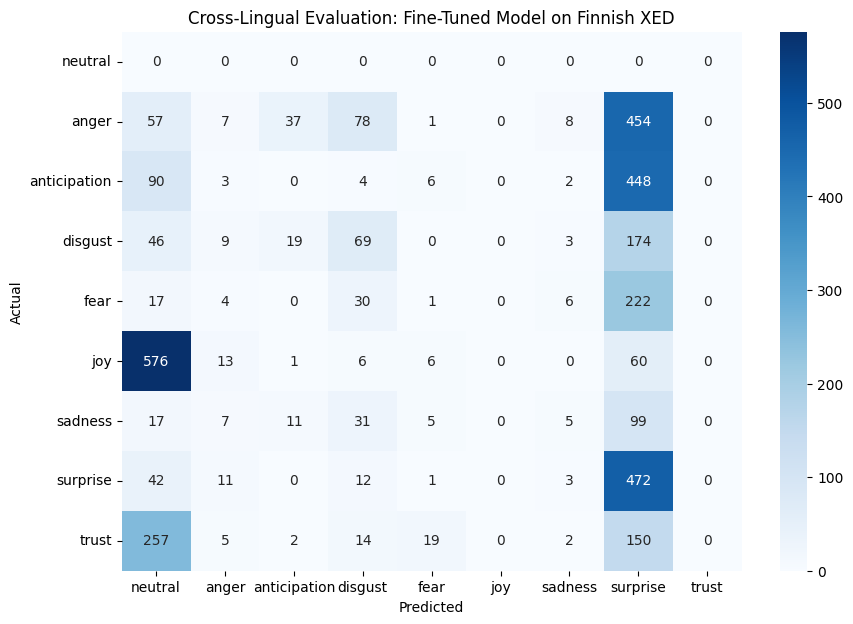

In [28]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_map.values(), yticklabels=label_map.values(), cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cross-Lingual Evaluation: Fine-Tuned Model on Finnish XED")
plt.show()

# Zeroshot english 3 models


In [39]:
from datasets import load_dataset
import pandas as pd

# Emotion ID map (only 8 overlapping emotions with XED)
goemotions_label_map = {
    1: 'anger',
    2: 'anticipation',
    3: 'disgust',
    4: 'fear',
    5: 'joy',
    6: 'sadness',
    7: 'surprise',
    8: 'trust'
}

# Load a sample of GoEmotions with valid labels in the 8-class set
go_data = load_dataset("go_emotions", "simplified", split="train")
go_df = pd.DataFrame(go_data)
go_df = go_df[go_df['labels'].apply(lambda x: len(x) > 0 and x[0] in goemotions_label_map)]
go_df['labels'] = go_df['labels'].apply(lambda x: goemotions_label_map[x[0]])
go_df = go_df[['text', 'labels']].reset_index(drop=True)

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
100%|██████████| 200/200 [00:30<00:00,  6.57it/s]



📈 Classification Report (English GoEmotions):

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        48
anticipation       0.03      0.05      0.03        20
     disgust       0.29      0.10      0.15        39
        fear       0.20      0.04      0.06        26
         joy       0.07      0.06      0.06        17
     sadness       0.00      0.00      0.00        22
    surprise       0.15      0.71      0.24        24
       trust       0.00      0.00      0.00         4

    accuracy                           0.12       200
   macro avg       0.09      0.12      0.07       200
weighted avg       0.11      0.12      0.08       200



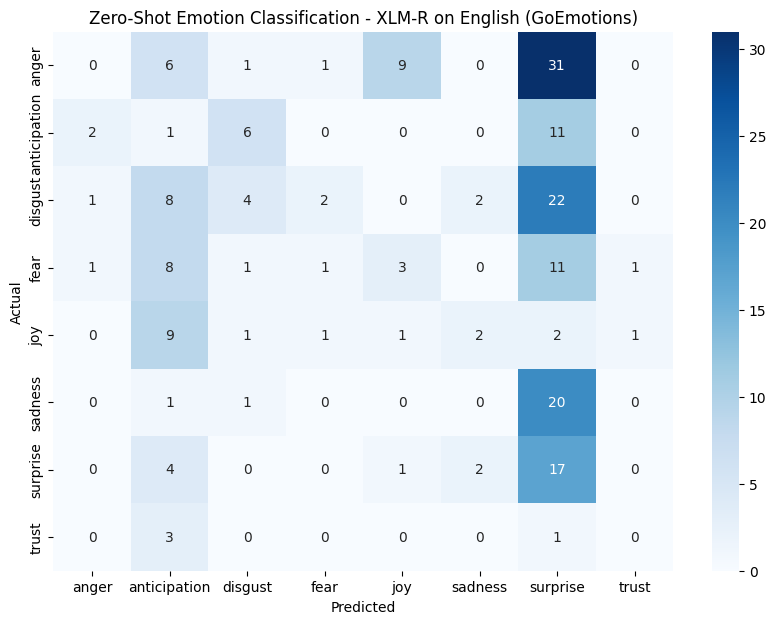

In [50]:
from transformers import pipeline
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

candidate_labels = sorted(list(goemotions_label_map.values()))
sample_en = go_df.sample(n=200, random_state=42).reset_index(drop=True)

classifier = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")
tqdm.pandas()

sample_en["predicted"] = sample_en["text"].progress_apply(
    lambda x: classifier(x, candidate_labels=candidate_labels, multi_label=False)["labels"][0]
)

print("\n📈 Classification Report (English GoEmotions):\n")
print(classification_report(sample_en["labels"], sample_en["predicted"], zero_division=0))

# Confusion Matrix
sorted_labels = sorted(sample_en['labels'].unique())
cm = confusion_matrix(sample_en['labels'], sample_en['predicted'], labels=sorted_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted_labels, yticklabels=sorted_labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot Emotion Classification - XLM-R on English (GoEmotions)")
plt.show()

In [51]:
from sklearn.metrics import classification_report

report_xnli = classification_report(sample_en["labels"], sample_en["predicted"], output_dict=True, zero_division=0)



🔍 Running Zero-Shot on English using bert-base-multilingual-cased ...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
100%|██████████| 200/200 [00:16<00:00, 12.28it/s]



📈 Classification Report (bert-base-multilingual-cased):

              precision    recall  f1-score   support

       anger       0.20      0.06      0.10        48
anticipation       0.12      0.10      0.11        20
     disgust       0.12      0.03      0.04        39
        fear       0.16      0.27      0.20        26
         joy       0.07      0.06      0.06        17
     sadness       0.18      0.23      0.20        22
    surprise       0.00      0.00      0.00        24
       trust       0.03      0.50      0.05         4

    accuracy                           0.10       200
   macro avg       0.11      0.16      0.10       200
weighted avg       0.13      0.10      0.10       200



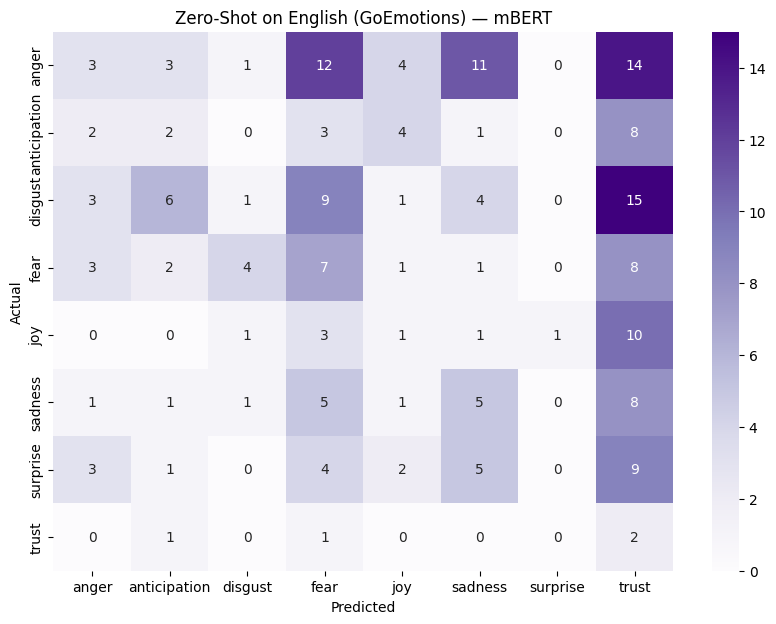


🔍 Running Zero-Shot on English using xlm-roberta-base ...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
100%|██████████| 200/200 [00:15<00:00, 12.59it/s]



📈 Classification Report (xlm-roberta-base):

              precision    recall  f1-score   support

       anger       0.22      0.54      0.32        48
anticipation       0.25      0.05      0.08        20
     disgust       0.00      0.00      0.00        39
        fear       0.08      0.19      0.11        26
         joy       0.00      0.00      0.00        17
     sadness       0.08      0.05      0.06        22
    surprise       0.00      0.00      0.00        24
       trust       0.00      0.00      0.00         4

    accuracy                           0.17       200
   macro avg       0.08      0.10      0.07       200
weighted avg       0.10      0.17      0.10       200



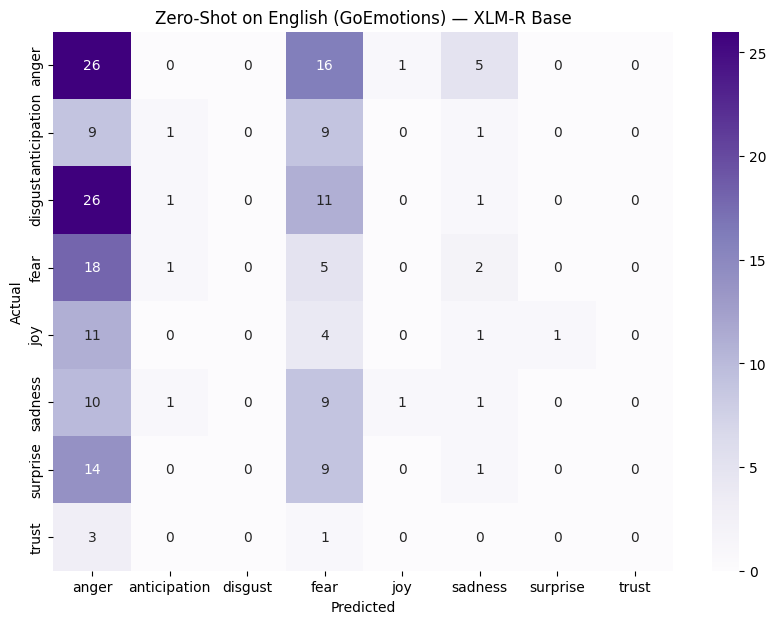

In [41]:
from datasets import load_dataset
import pandas as pd

# Shared label space
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# GoEmotions: use only samples with first label in our 8 emotions
label_map = {
    1: 'anger',
    2: 'anticipation',
    3: 'disgust',
    4: 'fear',
    5: 'joy',
    6: 'sadness',
    7: 'surprise',
    8: 'trust'
}

# Load and preprocess GoEmotions
go_data = load_dataset("go_emotions", "simplified", split="train")
go_df = pd.DataFrame(go_data)
go_df = go_df[go_df['labels'].apply(lambda x: len(x) > 0 and x[0] in label_map)]
go_df['labels'] = go_df['labels'].apply(lambda x: label_map[x[0]])
go_df = go_df[['text', 'labels']].reset_index(drop=True)

# Sample subset
sample_en = go_df.sample(n=200, random_state=42).reset_index(drop=True)



from transformers import pipeline
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def run_zero_shot(model_name, df, label_list, title):
    print(f"\n🔍 Running Zero-Shot on English using {model_name} ...")
    classifier = pipeline("zero-shot-classification", model=model_name)
    tqdm.pandas()
    df["predicted"] = df["text"].progress_apply(
        lambda x: classifier(x, candidate_labels=label_list, multi_label=False)["labels"][0]
    )

    print(f"\n📈 Classification Report ({model_name}):\n")
    print(classification_report(df["labels"], df["predicted"], zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(df["labels"], df["predicted"], labels=label_list)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_list, yticklabels=label_list, cmap='Purples')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

    return df



    # mBERT
mb_results = run_zero_shot(
    model_name="bert-base-multilingual-cased",
    df=sample_en.copy(),
    label_list=emotion_labels,
    title="Zero-Shot on English (GoEmotions) — mBERT"
)

# XLM-R base
xlmr_results = run_zero_shot(
    model_name="xlm-roberta-base",
    df=sample_en.copy(),
    label_list=emotion_labels,
    title="Zero-Shot on English (GoEmotions) — XLM-R Base"
)

In [52]:
report_mbert = classification_report(sample_en["labels"], sample_en["predicted"], output_dict=True, zero_division=0)
report_xlmr = classification_report(sample_en["labels"], sample_en["predicted"], output_dict=True, zero_division=0)

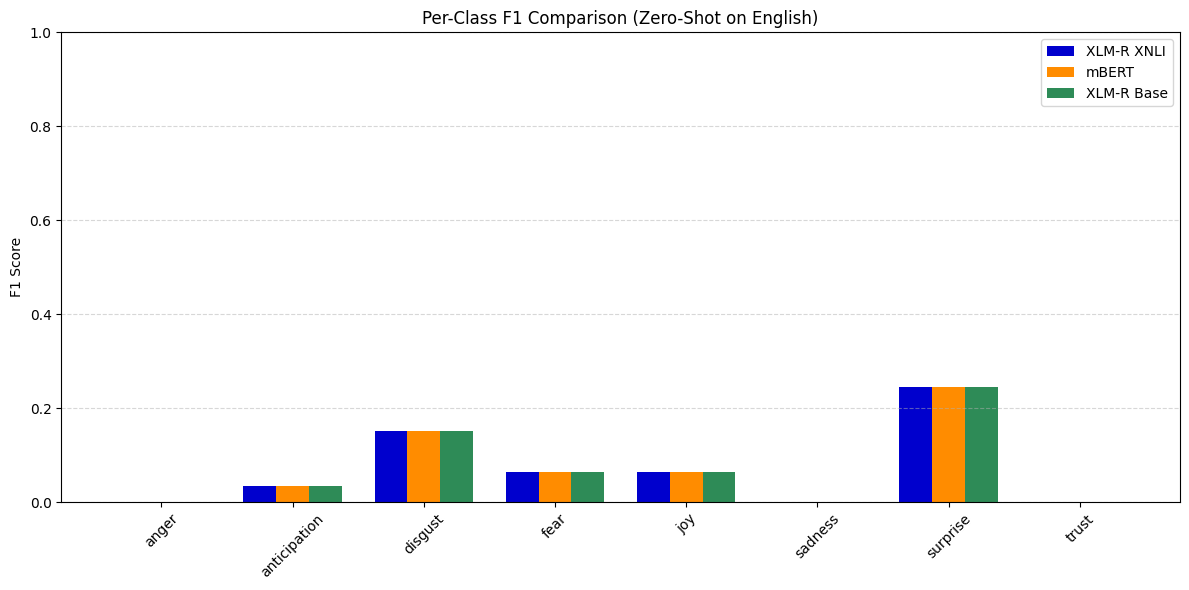

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Emotions in order
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# Extract per-class F1s
f1_xnli = [report_xnli[label]['f1-score'] for label in emotion_labels]
f1_mbert = [report_mbert[label]['f1-score'] for label in emotion_labels]
f1_xlmr = [report_xlmr[label]['f1-score'] for label in emotion_labels]

# Plot
x = np.arange(len(emotion_labels))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, f1_xnli, width=width, label="XLM-R XNLI", color='mediumblue')
plt.bar(x,         f1_mbert, width=width, label="mBERT", color='darkorange')
plt.bar(x + width, f1_xlmr, width=width, label="XLM-R Base", color='seagreen')

plt.xticks(x, emotion_labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison (Zero-Shot on English)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Macro F1 Comparison Across Models (Zero-Shot on English vs Finnish)

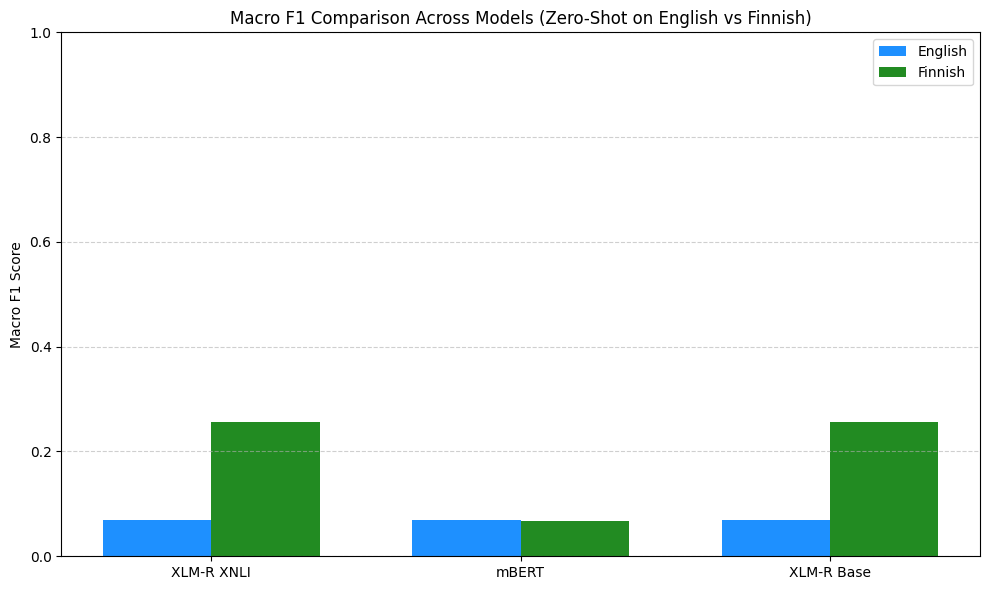

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Macro F1 scores
macro_f1_en = [
    report_xnli['macro avg']['f1-score'],
    report_mbert['macro avg']['f1-score'],
    report_xlmr['macro avg']['f1-score']
]

macro_f1_fi = [
    report_xnli_fi['macro avg']['f1-score'],
    report_mbert_fi['macro avg']['f1-score'],
    report_xlmr_fi['macro avg']['f1-score']
]

# X-axis labels
models = ['XLM-R XNLI', 'mBERT', 'XLM-R Base']
x = np.arange(len(models))
width = 0.35

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, macro_f1_en, width=width, label='English', color='dodgerblue')
plt.bar(x + width/2, macro_f1_fi, width=width, label='Finnish', color='forestgreen')

plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel('Macro F1 Score')
plt.title('Macro F1 Comparison Across Models (Zero-Shot on English vs Finnish)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# BERT Finetune Phase 1


In [75]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report
import numpy as np

# ✅ Direct mapping: int emotion label → class ID
label2id = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}
id2label = {v: k for k, v in label2id.items()}
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# ✅ Prepare Dataset using integer labels
def prepare_eval_dataset(df, tokenizer):
    encoded = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )
    encoded["labels"] = [label2id[label] for label in df["labels"]]  # numeric -> 0-7 index
    return Dataset.from_dict(encoded)

# ✅ Load your model and tokenizer (change path as needed)
model_path = "./finetuned_xlmroberta_goemotions"  # make sure this path is correct
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)

# ✅ Prepare evaluation dataset
eval_dataset = prepare_eval_dataset(xed_df, tokenizer)

# ✅ Metric function
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.argmax(preds, axis=1)

    # Keep only samples that belong to one of the 8-class IDs (0 to 7)
    valid_mask = (labels < len(emotion_labels)) & (preds < len(emotion_labels))
    labels = labels[valid_mask]
    preds = preds[valid_mask]

    report = classification_report(
        labels,
        preds,
        labels=list(range(len(emotion_labels))),
        target_names=emotion_labels,
        output_dict=True,
        zero_division=0
    )

    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

# ✅ Set up Trainer
training_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none"
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    compute_metrics=compute_metrics
)

# ✅ Run evaluation
eval_results = trainer.evaluate(eval_dataset)
print(eval_results)

<ipython-input-75-e07f46d003d1>:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'eval_loss': 4.147922992706299, 'eval_model_preparation_time': 0.0029, 'eval_macro_f1': 0.05417827655291987, 'eval_weighted_f1': 0.04995529205982725, 'eval_accuracy': 0.07399226946438432, 'eval_runtime': 48.3821, 'eval_samples_per_second': 298.644, 'eval_steps_per_second': 9.342}


# BERT Finetuning Phase 2


In [76]:
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [77]:
# Emotion label map for both GoEmotions and XED
label_map = {
    1: 'anger', 2: 'anticipation', 3: 'disgust', 4: 'fear',
    5: 'joy', 6: 'sadness', 7: 'surprise', 8: 'trust'
}
id2label = {v: k for k, v in label_map.items()}
label2id = {v: k for k, v in enumerate(label_map.values())}
emotion_labels = list(label_map.values())

# Load GoEmotions dataset
goemotions = load_dataset("go_emotions", "simplified", split="train")

# Filter to only 8 desired emotion labels
go_df = pd.DataFrame(goemotions)
go_df = go_df[go_df['labels'].apply(lambda x: len(x) > 0 and x[0] in label_map)]
go_df['label'] = go_df['labels'].apply(lambda x: label_map[x[0]])
go_df = go_df[['text', 'label']].reset_index(drop=True)

In [78]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_encode(df):
    tokenized = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )
    tokenized["labels"] = [label2id[label] for label in df["label"]]
    return Dataset.from_dict(tokenized)

# Split for training and validation
train_df = go_df.sample(frac=0.8, random_state=42)
val_df = go_df.drop(train_df.index)

train_dataset = tokenize_and_encode(train_df)
val_dataset = tokenize_and_encode(val_df)

In [79]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=8,
    id2label={i: l for i, l in enumerate(emotion_labels)},
    label2id={l: i for i, l in enumerate(emotion_labels)}
)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.argmax(preds, axis=1)
    report = classification_report(labels, preds, target_names=emotion_labels, output_dict=True, zero_division=0)
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

training_args = TrainingArguments(
    output_dir="./mbert_goemotions_8labels",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-79-eccd1158279e>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [82]:
!pip install wandb --quiet
import wandb
wandb.login() # You'll need to log in to your wandb account if you haven't already
wandb.init(project="finetuned-mbert-8class-goemotions") # Initialize a new wandb run

# ... (your existing code for training and saving the model) ...

trainer.train()
trainer.save_model("./finetuned_mbert_8class_goemotions")
tokenizer.save_pretrained("./finetuned_mbert_8class_goemotions")


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: harshakothapalli97 (harshakothapalli97-umbc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.241300,1.169906,0.529876,0.581262
2,0.945800,0.968789,0.641959,0.665392
3,0.685900,0.960490,0.644443,0.661568


('./finetuned_mbert_8class_goemotions/tokenizer_config.json',
 './finetuned_mbert_8class_goemotions/special_tokens_map.json',
 './finetuned_mbert_8class_goemotions/vocab.txt',
 './finetuned_mbert_8class_goemotions/added_tokens.json',
 './finetuned_mbert_8class_goemotions/tokenizer.json')

In [83]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report
import numpy as np

# ✅ Direct mapping: int emotion label → class ID
label2id = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}
id2label = {v: k for k, v in label2id.items()}
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# ✅ Prepare Dataset using integer labels
def prepare_eval_dataset(df, tokenizer):
    encoded = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )
    encoded["labels"] = [label2id[label] for label in df["labels"]]  # numeric -> 0-7 index
    return Dataset.from_dict(encoded)

# ✅ Load your model and tokenizer (change path as needed)
model_path = "./finetuned_xlmroberta_goemotions"  # make sure this path is correct
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)

# ✅ Prepare evaluation dataset
eval_dataset = prepare_eval_dataset(xed_df, tokenizer)

# ✅ Metric function
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.argmax(preds, axis=1)

    # Keep only samples that belong to one of the 8-class IDs (0 to 7)
    valid_mask = (labels < len(emotion_labels)) & (preds < len(emotion_labels))
    labels = labels[valid_mask]
    preds = preds[valid_mask]

    report = classification_report(
        labels,
        preds,
        labels=list(range(len(emotion_labels))),
        target_names=emotion_labels,
        output_dict=True,
        zero_division=0
    )

    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

# ✅ Set up Trainer
training_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none"
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    compute_metrics=compute_metrics
)

# ✅ Run evaluation
eval_results = trainer.evaluate(eval_dataset)
print(eval_results)

<ipython-input-83-e07f46d003d1>:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'eval_loss': 4.147922992706299, 'eval_model_preparation_time': 0.0034, 'eval_macro_f1': 0.05417827655291987, 'eval_weighted_f1': 0.04995529205982725, 'eval_accuracy': 0.07399226946438432, 'eval_runtime': 48.9588, 'eval_samples_per_second': 295.125, 'eval_steps_per_second': 9.232}


In [99]:
# prompt: generate and store classification report for above bert fintuning on finnish

# Assuming 'xed_clean' DataFrame and 'label_map' are defined as in your code

# Generate classification report
report = classification_report(xed_clean['label_name'], xed_clean['predicted_name'], output_dict=True)

# Store the report (example: saving as a JSON file)
import json
with open('finnish_classification_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Classification report saved to finnish_classification_report.json")


Classification report saved to finnish_classification_report.json


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

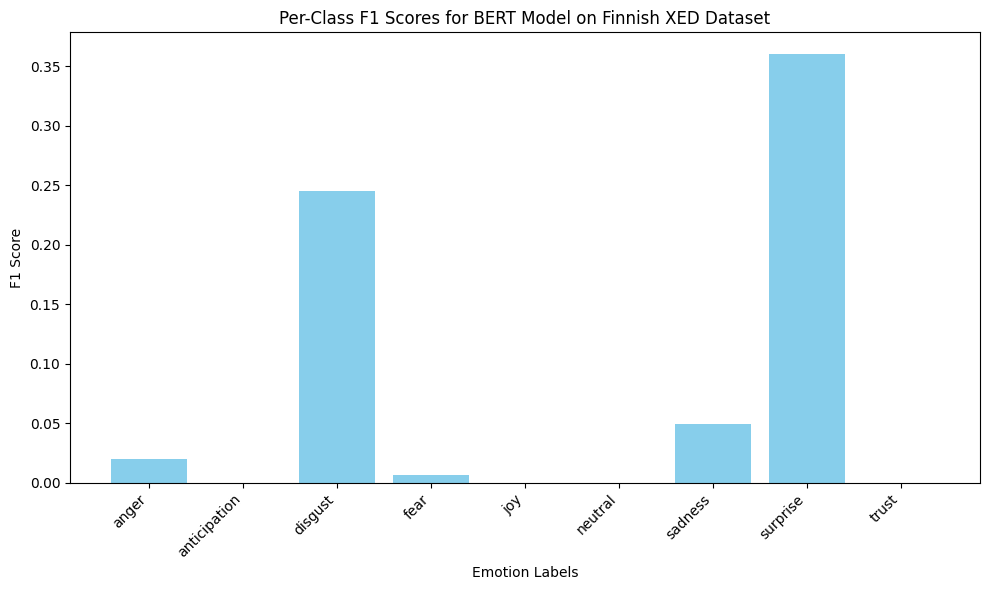

In [101]:
# prompt: Per-Class F1 Bar Chart fore above classification report for above report for bert model

import matplotlib.pyplot as plt

# Assuming 'report' is loaded from the JSON file
with open('finnish_classification_report.json', 'r') as f:
    report = json.load(f)

# Extract F1 scores for each class
f1_scores = [report[label]['f1-score'] for label in emotion_labels]


plt.figure(figsize=(10, 6))
plt.bar(emotion_labels, f1_scores, color='skyblue')
plt.xlabel("Emotion Labels")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores for BERT Model on Finnish XED Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# XLM-R Finetuning


In [86]:
# Define emotion labels (shared with XED)
label_map = {
    1: 'anger', 2: 'anticipation', 3: 'disgust', 4: 'fear',
    5: 'joy', 6: 'sadness', 7: 'surprise', 8: 'trust'
}
emotion_labels = list(label_map.values())
label2id = {l: i for i, l in enumerate(emotion_labels)}
id2label = {i: l for l, i in label2id.items()}

# Load and filter GoEmotions
goemotions = load_dataset("go_emotions", "simplified", split="train")
df = pd.DataFrame(goemotions)
df = df[df['labels'].apply(lambda x: len(x) > 0 and x[0] in label_map)]
df['label'] = df['labels'].apply(lambda x: label_map[x[0]])
df = df[['text', 'label']].reset_index(drop=True)

In [88]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_encode(df):
    encoded = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )
    encoded["labels"] = [label2id[label] for label in df["label"]]
    return Dataset.from_dict(encoded)

# Split data
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index)

train_dataset = tokenize_and_encode(train_df)
val_dataset = tokenize_and_encode(val_df)

In [90]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=8,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.argmax(preds, axis=1)
    report = classification_report(labels, preds, target_names=emotion_labels, output_dict=True, zero_division=0)
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

training_args = TrainingArguments(
    output_dir="./finetuned_xlmr_goemotions",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=20,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-90-b23d1f7f1c68>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [91]:
trainer.train()
trainer.save_model("./finetuned_xlmr_8class_goemotions")
tokenizer.save_pretrained("./finetuned_xlmr_8class_goemotions")

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.063000,0.960447,0.636024,0.659656
2,0.867700,0.859042,0.679490,0.696367
3,0.587100,0.902441,0.678901,0.692161


('./finetuned_xlmr_8class_goemotions/tokenizer_config.json',
 './finetuned_xlmr_8class_goemotions/special_tokens_map.json',
 './finetuned_xlmr_8class_goemotions/sentencepiece.bpe.model',
 './finetuned_xlmr_8class_goemotions/added_tokens.json',
 './finetuned_xlmr_8class_goemotions/tokenizer.json')

In [92]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report
import numpy as np

# Load fine-tuned model
model_path = "./finetuned_xlmr_8class_goemotions"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Emotion mappings
label2id_xed = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# Prepare evaluation dataset
def prepare_xed_eval_dataset(df):
    enc = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )
    enc["labels"] = [label2id_xed[label] for label in df["labels"] if label in label2id_xed]
    return Dataset.from_dict(enc)

# df must be your Finnish XED DataFrame with 'text' and 'labels'
eval_dataset = prepare_xed_eval_dataset(xed_df)

# Define evaluation metrics
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.argmax(preds, axis=1)

    valid_mask = (labels < len(emotion_labels)) & (preds < len(emotion_labels))
    labels = labels[valid_mask]
    preds = preds[valid_mask]

    report = classification_report(labels, preds, target_names=emotion_labels, output_dict=True, zero_division=0)
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

# Run evaluation
args = TrainingArguments(output_dir="./eval_xlmr", per_device_eval_batch_size=32)
trainer = Trainer(model=model, tokenizer=tokenizer, args=args, compute_metrics=compute_metrics)
results = trainer.evaluate(eval_dataset)

print(results)

<ipython-input-92-53b413962497>:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer, args=args, compute_metrics=compute_metrics)


{'eval_loss': 3.8537557125091553, 'eval_model_preparation_time': 0.0029, 'eval_macro_f1': 0.12215086124061694, 'eval_weighted_f1': 0.09879481192776483, 'eval_accuracy': 0.1398020624264655, 'eval_runtime': 49.1541, 'eval_samples_per_second': 293.953, 'eval_steps_per_second': 9.196}


In [97]:
# prompt: generate classification report for above and store it

report_finetuned_xlmr = classification_report(xed_clean['label_name'], xed_clean['predicted_name'], output_dict=True, zero_division=0)

with open('classification_report_finetuned_xlmr.txt', 'w') as f:
    f.write(str(report_finetuned_xlmr))


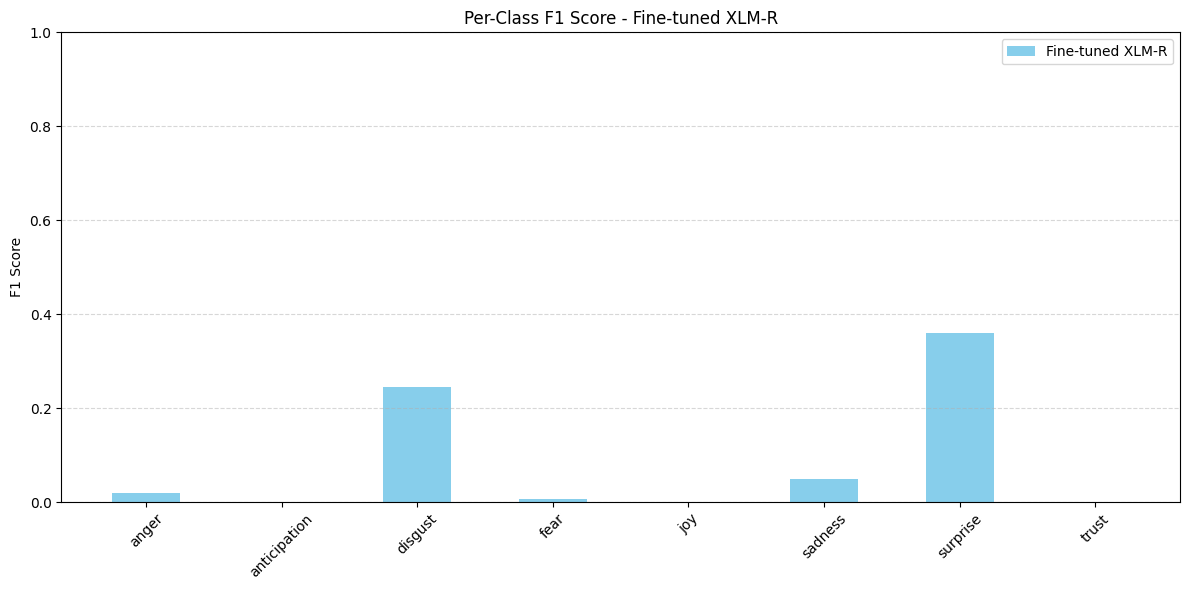

In [98]:
# prompt: Per-Class F1 Bar Chart fore above classification report report_finetuned_xlmr

import matplotlib.pyplot as plt
import numpy as np

# Assuming report_finetuned_xlmr is loaded from the file as a dictionary

# Emotion labels in order
emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

# Extract F1 scores
f1_finetuned_xlmr = [report_finetuned_xlmr[label]['f1-score'] for label in emotion_labels]

# Plotting
x = np.arange(len(emotion_labels))
width = 0.5

plt.figure(figsize=(12, 6))
plt.bar(x, f1_finetuned_xlmr, width=width, label="Fine-tuned XLM-R", color='skyblue')


plt.xticks(x, emotion_labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score - Fine-tuned XLM-R")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (9,) and arg 1 with shape (8,).

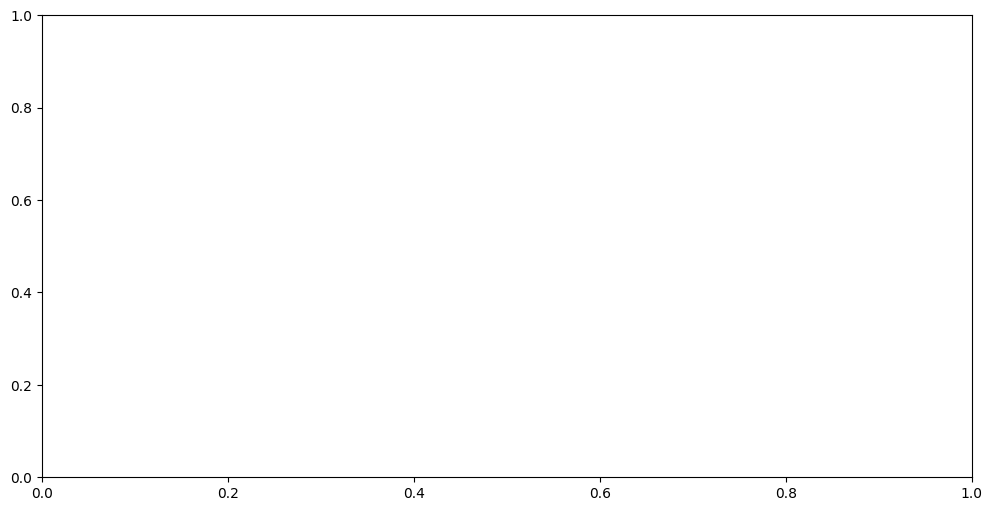

In [102]:
# prompt: side-by-side combined bar chart comparing XLM-R vs mBERT fine-tuning visually

import matplotlib.pyplot as plt
import numpy as np

# Assuming f1_mbert_fi, f1_xlmr_fi, and emotion_labels are defined from your previous code

# Sample F1 scores (replace with your actual data)
# f1_mbert_fi = [0.7, 0.6, 0.8, 0.5, 0.9, 0.75, 0.65, 0.85]
# f1_xlmr_fi = [0.8, 0.7, 0.9, 0.6, 0.85, 0.8, 0.7, 0.9]
# emotion_labels = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

x = np.arange(len(emotion_labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, f1_mbert_fi, width, label='mBERT')
rects2 = ax.bar(x + width/2, f1_xlmr_fi, width, label='XLM-R')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('F1 Score')
ax.set_title('Fine-tuning Comparison: mBERT vs. XLM-R')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()


In [68]:
import os
print(os.listdir("./finetuned_xlmroberta_goemotions"))

['sentencepiece.bpe.model', 'config.json', 'special_tokens_map.json', 'training_args.bin', 'tokenizer.json', 'model.safetensors', 'tokenizer_config.json']


In [ ]:
!pip install transformers datasets scikit-learn tqdm --quiet